In [17]:
# !pip install pygame
# !pip install gym
import gym
import collections
import numpy as np


def discretize(observation, bins):
    discrete_obs = [np.digitize(obs, bins[i]) for i, obs in enumerate(observation)]
    return tuple(discrete_obs)

def choose_action(Q, state, epsilon, env):
    
    if state not in Q or np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

def update_Q(Q, alpha, episode, gamma):
    states, actions, rewards = zip(*episode)
    discounts = np.array([gamma**i for i in range(len(rewards)+1)])
    for i, state in enumerate(states):
        old_Q = Q[state][actions[i]]
        G_t = sum(rewards[i:]*discounts[:-(1+i)])
        Q[state][actions[i]] = old_Q + alpha * (G_t - old_Q)

def train(env, episodes=5000, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01, alpha=0.1):
    num_bins = (6, 12, 12, 24)  # Define the number of bins for each observation
    bins = [
        np.linspace(-2.4, 2.4, num_bins[0]),
        np.linspace(-5, 5, num_bins[1]),
        np.linspace(-0.418, 0.418, num_bins[2]),
        np.linspace(-5, 5, num_bins[3])
    ]

    Q = collections.defaultdict(lambda: np.zeros(env.action_space.n))
    rewards = []
    avg_reward = []
    for episode in range(episodes):
        
        state = discretize(env.reset()[0], bins)
        episode_data = []
        done = False

        while not done:
            action = choose_action(Q, state, epsilon, env)
            next_state, reward, done, i,j = env.step(action)
            next_state = discretize(next_state, bins)
            episode_data.append((state, action, reward))
            state = next_state

        rewards.append(sum([r for (_, _, r) in episode_data]))
        update_Q(Q, alpha, episode_data, gamma)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if episode >= 100 and np.mean(rewards[-100:]) >= 195.0:
            avg_reward.append(np.mean(rewards[-100:]))
            print(f"Solved in {episode + 1} episodes! with reward: {np.mean(rewards[-100:])}")
            break

        if (episode + 1) % 100 == 0:
            avg_reward.append(np.mean(rewards[-100:]))
            print(f"Episode {episode + 1}, Average Reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")
    return avg_reward
env = gym.make('CartPole-v1')
avg_reward = train(env)

Episode 100, Average Reward (last 100 episodes): 30.46
Episode 200, Average Reward (last 100 episodes): 79.29
Episode 300, Average Reward (last 100 episodes): 89.29
Episode 400, Average Reward (last 100 episodes): 110.19
Episode 500, Average Reward (last 100 episodes): 128.66
Episode 600, Average Reward (last 100 episodes): 103.21
Episode 700, Average Reward (last 100 episodes): 192.15
Solved in 701 episodes! with reward: 195.13


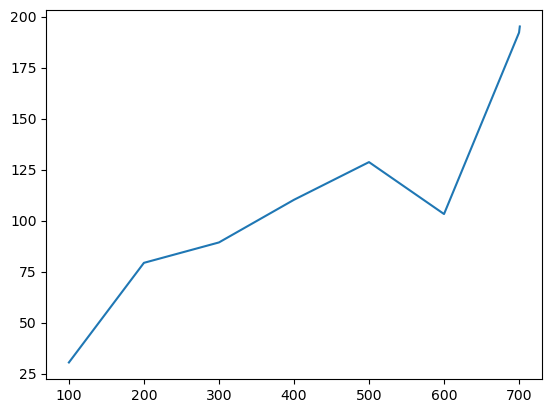

In [20]:
import matplotlib.pyplot as plt
x= np.arange(100,801,100)
x[-1] = 701
plt.plot(x,avg_reward)
plt.show()